In [1]:
import torch
import models as m
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid

In [2]:
torch.set_default_dtype(torch.float32)

if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

def t(x):
    return torch.as_tensor(x, dtype=torch.get_default_dtype(), device=device)

Using device: cuda:0


In [3]:
BASE_PATH = os.getcwd()
RUNS_ROOT = os.path.join(BASE_PATH, "runs")

EXP_NAME = "comparaison"   
RUN_ID = "001"                  

EXP_DIR = os.path.join(RUNS_ROOT, EXP_NAME)
RUN_DIR = os.path.join(EXP_DIR, RUN_ID)
WEIGHTS_DIR = os.path.join(RUN_DIR, "weights")
LOGS_DIR = os.path.join(RUN_DIR, "logs")
SAMPLES_DIR = os.path.join(RUN_DIR, "samples_pc")
os.makedirs(SAMPLES_DIR, exist_ok=True)

with open(os.path.join(LOGS_DIR, "hparams.json"), "r") as f:
    hparams = json.load(f)

print("Loaded hparams from:", RUN_DIR)
print("sigma hyperparams:", hparams["sigma"])
print("img_size:", hparams["img_size"])

sigma_min = hparams["sigma"]["min"]
sigma_max = hparams["sigma"]["max"]

img_size = hparams["img_size"]
C = hparams["model"]["in_channel"]
H = W = img_size

Loaded hparams from: /home/infres/rplanchon-23/code/DSM/src/VE-SDE/celebA/runs/comparaison/001
sigma hyperparams: {'min': 0.01, 'max': 1.5}
img_size: 64


In [4]:
state_dict = torch.load(
    os.path.join(WEIGHTS_DIR, "model.pt"),
    map_location=device,
    weights_only=True,
)

model = m.SmallUNetSigma(
    in_ch=hparams["model"]["in_channel"],
    base_ch=hparams["model"]["base_ch"],
    channel_mults=hparams["model"]["channel_mults"],
    emb_dim=hparams["model"]["sigma_emb_dim"],
).to(device)

model.load_state_dict(state_dict)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"Model has {total_params/1e6:.2f}M parameters")

Model has 47.26M parameters


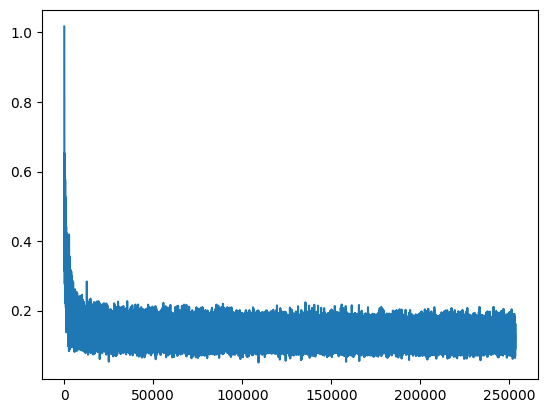

In [5]:
Loss = np.load(os.path.join(LOGS_DIR,'train_loss.npy'))
steps_eval = np.load(os.path.join(LOGS_DIR,'steps_eval.npy'))
plt.plot(Loss)
plt.show()


In [6]:
# VE schedule σ(t) and g(t)
# Training: log σ(t) = log σ_min + t (log σ_max - log σ_min), t ∈ [0,1]

log_sigma_min = t(sigma_min).log()
log_sigma_max = t(sigma_max).log()
log_r = log_sigma_max - log_sigma_min   # log(σ_max / σ_min)

def sigma_of_t(t_scalar):
    """
    t_scalar: scalaire ou tensor in [0,1]
    returns σ(t) avec même dtype/device.
    """
    return torch.exp(log_sigma_min + t_scalar * log_r)

def g_of_t(t_scalar):
    """
    g(t) = sqrt(d/dt σ^2(t))
         = sqrt(2 log(σ_max/σ_min)) * σ(t)
    car σ^2(t) = σ_min^2 * (σ_max/σ_min)^{2t}.
    """
    sigma_t = sigma_of_t(t_scalar)
    return torch.sqrt(2.0 * log_r) * sigma_t

# Sanity check
for val in [0.0, 0.5, 1.0]:
    s = sigma_of_t(t(val))
    g = g_of_t(t(val))
    print(f"t={val:.2f} -> sigma={s.item():.4f}, g={g.item():.4f}")

t=0.00 -> sigma=0.0100, g=0.0317
t=0.50 -> sigma=0.1225, g=0.3877
t=1.00 -> sigma=1.5000, g=4.7485


In [7]:
# Predictor: reverse VE SDE 
@torch.no_grad()
def predictor_step(x, t_k, t_prev):
    """
    Reverse VE SDE:
      dx = -g(t)^2 s_theta(x,t) dt + g(t) dW_t, t: 1 -> 0.

    Discrétisation t_k -> t_prev < t_k:
      x_{k-1} = x_k
        - g(t_k)^2 s_theta(x_k,t_k) * |Δt|
        + g(t_k) sqrt(|Δt|) z_k,
      avec Δt = t_prev - t_k < 0.
    """
    
    dt = t_prev - t_k  # négatif
    assert (dt <= 0).all()

    sigma_k = sigma_of_t(t_k)  
    g_k = g_of_t(t_k)         

    B = x.shape[0]
    sigma_batch = sigma_k.view(1, 1).expand(B, 1)  # (B,1)
    score = model(x, sigma_batch)                  # (B,C,H,W)

    noise = torch.randn_like(x)
    x = x + (-g_k**2 * score) * dt + g_k * torch.sqrt(-dt) * noise
    return x

In [8]:
# Corrector: simple Langevin at fixed t 
@torch.no_grad()
def corrector_step(x, t_k, n_steps, base_eps=1e-4):
    """
    Correcteur Langevin classique à temps fixé t_k :
      x^{(m+1)} = x^{(m)} + ε_k s_theta(x^{(m)}, t_k) + sqrt(2 ε_k) z^{(m)}

    ε_k = base_eps * σ(t_k)^2
    """
    
    if n_steps <= 0:
        return x

    sigma_k = sigma_of_t(t_k)
    eps_k = base_eps * sigma_k**2

    for _ in range(n_steps):
        B = x.shape[0]
        sigma_batch = sigma_k.view(1, 1).expand(B, 1)  # (B,1)
        score = model(x, sigma_batch)

        noise = torch.randn_like(x)
        x = x + eps_k * score + torch.sqrt(2.0 * eps_k) * noise

    return x

In [9]:
def minmax_renorm_to_minus1_1(x):
    """
    x: (B, C, H, W)
    Renormalise chaque image individuellement dans [-1,1]
    via (x - min) / (max - min) * 2 - 1
    où min/max sont pris sur (C,H,W) pour chaque image.
    """
    B = x.shape[0]
    x_flat = x.view(B, -1)                  # (B, C*H*W)
    x_min = x_flat.min(dim=1).values.view(B, 1, 1, 1)
    x_max = x_flat.max(dim=1).values.view(B, 1, 1, 1)

    # éviter la division par 0
    denom = (x_max - x_min).clamp_min(1e-8)

    x_scaled = (x - x_min) / denom          # dans [0,1]
    x_scaled = x_scaled * 2.0 - 1.0         # dans [-1,1]
    return x_scaled


# PC sampler
@torch.no_grad()
def pc_sampler_ve(num_samples=4,num_steps=1000,n_corrector_steps=1,corrector_base_eps=1e-4):
    """
    Sampler VE SDE avec Predictor–Corrector :
    - t_0 = 0 < ... < t_N = 1, on itère de N -> 0.
    - Predictor: Euler–Maruyama sur la reverse SDE.
    - Corrector: Langevin avec ε_k = base_eps * σ(t_k)^2.
    - Prior: x_T ~ N(0, σ_max^2 I).

    """

    # grille de temps
    t_grid = torch.linspace(0.0, 1.0, num_steps + 1, device=device)
    t_grid_rev = t_grid.flip(0)  # [1, ..., 0]

    # prior p_T = N(0, σ_max^2 I)
    x = torch.randn(num_samples, C, H, W, device=device) * sigma_max
    print(f"Init shape: {x.shape}, prior σ_max={sigma_max}")

    # indices de snapshots: début, 25%, 50%, 75%, fin
    snapshot_fracs = [0.0, 0.25, 0.5, 0.75, 1.0]
    snapshot_indices = sorted(
        {int(frac * num_steps) for frac in snapshot_fracs}
    )  # unique + trié
    print("Snapshot steps:", snapshot_indices)

    snapshots = {}  # step -> tensor (num_samples, C, H, W)

    # snapshot initial (avant toute update)
    snapshots[0] = x.clone()

    for i in range(num_steps):
        t_k = t_grid_rev[i]      # temps courant
        t_prev = t_grid_rev[i+1] # temps suivant (plus proche de 0)

        # predictor
        x = predictor_step(x, t_k, t_prev)

        # corrector
        x = corrector_step(x, t_k, n_corrector_steps, base_eps=corrector_base_eps)

        # sauvegarde snapshot si index match
        step_id = i + 1
        if step_id in snapshot_indices:
            snapshots[step_id] = x.clone()

        if (i + 1) % max(1, num_steps // 10) == 0:
            print(f"[{i+1}/{num_steps}] t={t_k.item():.4f}")

    x_renorm = minmax_renorm_to_minus1_1(x)

    # renorm aussi les snapshots (si tu veux les afficher ensuite)
    snapshots_renorm = {}
    for k, x_snap in snapshots.items():
        snapshots_renorm[k] = minmax_renorm_to_minus1_1(x_snap)

    return x_renorm, snapshots_renorm

 

In [10]:
def per_image_minmax_to_01(x):
    """
    x : (B, C, H, W)
    Pour chaque image du batch, fait :
        x -> (x - min) / (max - min)  dans [0,1]
    avec min/max pris sur (C,H,W) de chaque image séparément.
    """
    B = x.shape[0]
    x_flat = x.view(B, -1)                        # (B, C*H*W)
    x_min = x_flat.min(dim=1).values.view(B, 1, 1, 1)
    x_max = x_flat.max(dim=1).values.view(B, 1, 1, 1)
    denom = (x_max - x_min).clamp_min(1e-8)
    x_01 = (x - x_min) / denom
    return x_01


#### PC SAMPLER VE classique

In [11]:
# Run sampler and visualize snapshots 
num_samples = 8
num_steps = 500
n_corrector_steps = 10
corrector_base_eps = 5e-3


x_final, snapshots = pc_sampler_ve(
    num_samples=num_samples,
    num_steps=num_steps,
    n_corrector_steps=n_corrector_steps,
    corrector_base_eps=corrector_base_eps,
)


Init shape: torch.Size([8, 3, 64, 64]), prior σ_max=1.5
Snapshot steps: [0, 125, 250, 375, 500]
[50/500] t=0.9020
[100/500] t=0.8020
[150/500] t=0.7020
[200/500] t=0.6020
[250/500] t=0.5020
[300/500] t=0.4020
[350/500] t=0.3020
[400/500] t=0.2020
[450/500] t=0.1020
[500/500] t=0.0020


Saved snapshots figure to: /home/infres/rplanchon-23/code/DSM/src/VE-SDE/celebA/runs/comparaison/001/samples_pc/snapshots_ve_pc_N500_corr10_eps0.005.png


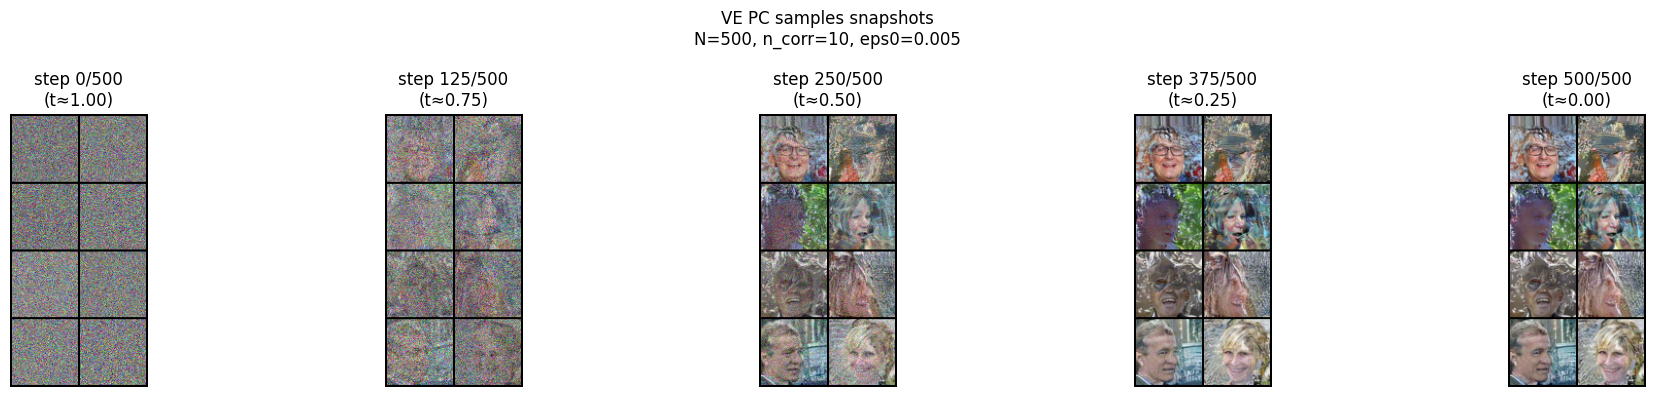

Saved final samples to: /home/infres/rplanchon-23/code/DSM/src/VE-SDE/celebA/runs/comparaison/001/samples_pc/samples_ve_pc_final_N500_corr10_eps0.005.png


In [13]:
# Renorm per-image pour affichage (dans [0,1])
x_final_vis = per_image_minmax_to_01(x_final)
snapshots_vis = {k: per_image_minmax_to_01(v) for k, v in snapshots.items()}

# On ordonne les snapshots par étape
sorted_steps = sorted(snapshots_vis.keys())

# Figure multi-snapshots : chaque colonne = un temps, lignes = images
n_cols = len(sorted_steps)
n_rows = 1  # on affiche un grid par snapshot

plt.figure(figsize=(4 * n_cols, 4))
for col, step_id in enumerate(sorted_steps):
    x_snap_vis = snapshots_vis[step_id]
    grid = make_grid(
        x_snap_vis,
        nrow=int(np.sqrt(num_samples))
    )
    plt.subplot(1, n_cols, col + 1)
    plt.imshow(grid.permute(1, 2, 0).detach().cpu().numpy())
    plt.axis("off")
    frac = step_id / num_steps
    plt.title(f"step {step_id}/{num_steps}\n(t≈{1-frac:.2f})")

plt.suptitle(
    f"VE PC samples snapshots\nN={num_steps}, n_corr={n_corrector_steps}, eps0={corrector_base_eps}"
)
# Sauvegarde de la figure snapshots
snap_save_path = os.path.join(
    SAMPLES_DIR,
    f"snapshots_ve_pc_N{num_steps}_corr{n_corrector_steps}_eps{corrector_base_eps}.png",
)
plt.savefig(snap_save_path, dpi=200, bbox_inches="tight")
print("Saved snapshots figure to:", snap_save_path)

plt.tight_layout()
plt.show()

# Et on sauvegarde aussi uniquement le grid final
final_grid = make_grid(x_final_vis, nrow=int(np.sqrt(num_samples)))
final_save_path = os.path.join(
    SAMPLES_DIR,
    f"samples_ve_pc_final_N{num_steps}_corr{n_corrector_steps}_eps{corrector_base_eps}.png",
)
plt.imsave(final_save_path, final_grid.permute(1, 2, 0).detach().cpu().numpy())
print("Saved final samples to:", final_save_path)


##### Test hyperparamètres samplings

In [22]:
# ============================================================
# Sweep d'hyperparamètres pour le sampler VE-PC
# ============================================================

# Tu peux ajuster cette liste comme tu veux
hyperparam_configs = [
    # Variante plus douce que ton meilleur actuel
    # dict(num_steps=1500, n_corrector_steps=2, corrector_base_eps=0.03),
    # dict(num_steps=1500, n_corrector_steps=2, corrector_base_eps=0.04),

    # # On garde eps0 ~0.05 mais on joue sur N
    # dict(num_steps=2000, n_corrector_steps=2, corrector_base_eps=0.05),
    # dict(num_steps=2500, n_corrector_steps=2, corrector_base_eps=0.05),

    # # Test sur n_corr (voir si plus de petites corrections est mieux qu’un gros eps0)
    # dict(num_steps=1500, n_corrector_steps=3, corrector_base_eps=0.03),
    # dict(num_steps=2000, n_corrector_steps=3, corrector_base_eps=0.03),

    # # Variante « plus stable » si tu vois encore des artefacts
    # dict(num_steps=2000, n_corrector_steps=2, corrector_base_eps=0.02),
]


num_samples = 8  # ou 16 si tu veux des grids plus denses

all_grids = []
all_titles = []

for cfg in hyperparam_configs:
    N = cfg["num_steps"]
    n_corr = cfg["n_corrector_steps"]
    eps0 = cfg["corrector_base_eps"]

    print(f"Sampling with N={N}, n_corr={n_corr}, eps0={eps0} ...")

    # --- Run sampler ---
    x_final, _ = pc_sampler_ve(
        num_samples=num_samples,
        num_steps=N,
        n_corrector_steps=n_corr,
        corrector_base_eps=eps0,
    )

    # --- Visu final ---
    x_final_vis = per_image_minmax_to_01(x_final)
    final_grid = make_grid(x_final_vis, nrow=int(np.sqrt(num_samples)))

    all_grids.append(final_grid)
    all_titles.append(f"N={N}\n n_corr={n_corr}, eps0={eps0}")

    # Sauvegarde grid final par config
    final_save_path = os.path.join(
        SAMPLES_DIR,
        f"sweep_ve_pc_final_N{N}_corr{n_corr}_eps{eps0}.png",
    )
    plt.imsave(
        final_save_path,
        final_grid.permute(1, 2, 0).detach().cpu().numpy()
    )
    print("  → Saved final grid to:", final_save_path)

# ============================================================
# Figure récap : un subplot par combo d'hyperparamètres
# ============================================================

n_cfg = len(all_grids)
plt.figure(figsize=(4 * n_cfg, 4))

for i, (grid, title) in enumerate(zip(all_grids, all_titles)):
    plt.subplot(1, n_cfg, i + 1)
    plt.imshow(grid.permute(1, 2, 0).detach().cpu().numpy())
    plt.axis("off")
    plt.title(title)

plt.suptitle("VE PC sampler – sweep hyperparamètres")
plt.tight_layout()
plt.show()


<Figure size 0x400 with 0 Axes>

#### PC SAMPLER VE SDE SNR 

In [17]:
import torch
import math

# --------- VE SDE de base (forward) ---------
class VESDE:
    def __init__(self, sigma_min=0.01, sigma_max=50.0, N=1000):
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max
        self.N = N
        self._log_ratio = math.log(self.sigma_max) - math.log(self.sigma_min)

    def sigma(self, t):
        # t \in [0,1]
        return self.sigma_min * (self.sigma_max / self.sigma_min) ** t

    def g(self, t):
        # diffusion coeff g(t) s.t. dx = g(t) dW
        return torch.sqrt(torch.tensor(2.0 * self._log_ratio, device=t.device)) * self.sigma(t)

    def marginal_prob(self, x0, t):
        std = self.sigma(t)
        mean = x0
        return mean, std

    def prior_sampling(self, shape, device):
        # p(x_T) ~ N(0, sigma_max^2 I)
        return torch.randn(*shape, device=device) * self.sigma_max

sde = VESDE(sigma_min=sigma_min, sigma_max=sigma_max, N=1000)

# --------- Correcteur Langevin avec SNR (Song) ---------
def langevin_corrector_snr(x, t_vec, score_model, snr=0.16, n_steps=1):
    """
    x      : (B,C,H,W)
    t_vec  : (B,) times in [0,1]
    snr    : SNR cible (hyperparamètre du papier, ~0.16)
    n_steps: nombre de pas de correcteur par niveau de temps
    """
    target_snr = snr
    for _ in range(n_steps):
        grad = score_model(x, t_vec)             # score \approx ∇_x log p_t(x)
        noise = torch.randn_like(x)

        # normes moyennes sur le batch (comme dans score_sde_pytorch)
        grad_norm = torch.norm(grad.reshape(grad.shape[0], -1), dim=-1).mean()
        noise_norm = torch.norm(noise.reshape(noise.shape[0], -1), dim=-1).mean()

        # pas de Langevin imposant SNR(x_{k+1}-x_k) = target_snr
        step_size = ((target_snr * noise_norm / grad_norm) ** 2 * 2.0)
        step_size_t = step_size.view(1, 1, 1, 1)  # broadcast

        x_mean = x + step_size_t * grad
        x = x_mean + torch.sqrt(2.0 * step_size_t) * noise

    return x, x_mean


def pc_sampler_ve_snr(
    num_samples=8,
    num_steps=1000,
    n_corrector_steps=1,
    snr=0.16,
    eps=1e-5,
    snapshots_every=50
):
    model.eval()
    B = num_samples

    with torch.no_grad():
        C = 3
        H = W = img_size
        x = sde.prior_sampling((B, C, H, W), device=device)

        snapshots = {}
        t_grid = torch.linspace(1.0, eps, num_steps + 1, device=device)

        for i in range(num_steps):
            t      = t_grid[i].expand(B)          # temps courant
            t_next = t_grid[i + 1].expand(B)      # temps suivant (plus petit)
            dt = (t_next[0] - t[0]).item()        # < 0

            # -------- 1) Predictor : reverse VE SDE de t -> t_next --------
            g_t   = sde.g(t)                      # (B,)
            score = model(x, t)                   # (B,C,H,W)

            drift = -(g_t ** 2).view(B, 1, 1, 1) * score
            noise = torch.randn_like(x)

            x_mean = x + drift * dt
            x = x_mean + noise * torch.sqrt(torch.tensor(-dt, device=device)) \
                        * g_t.view(B, 1, 1, 1)

            # -------- 2) Corrector : Langevin SNR à t_next --------
            x, _ = langevin_corrector_snr(
                x, t_next, model,
                snr=snr,
                n_steps=n_corrector_steps
            )

            if (i % snapshots_every) == 0 or i == num_steps - 1:
                snapshots[i] = x.detach().cpu()

        return x, snapshots



##### TEST hyperparamètres

In [20]:
x_final_list = []
config_list = []

snr_list = [0.16]
num_steps_list = [1000]        
n_corrector_steps_list = [1]           

num_samples = 32

for snr in snr_list:
    for num_steps in num_steps_list:
        for n_corrector_steps in n_corrector_steps_list:
            x_final, _ = pc_sampler_ve_snr(
                num_samples=num_samples,
                num_steps=num_steps,
                n_corrector_steps=n_corrector_steps,
                snr=snr,
            )
            x_final_list.append(x_final)
            config_list.append((snr, num_steps, n_corrector_steps))


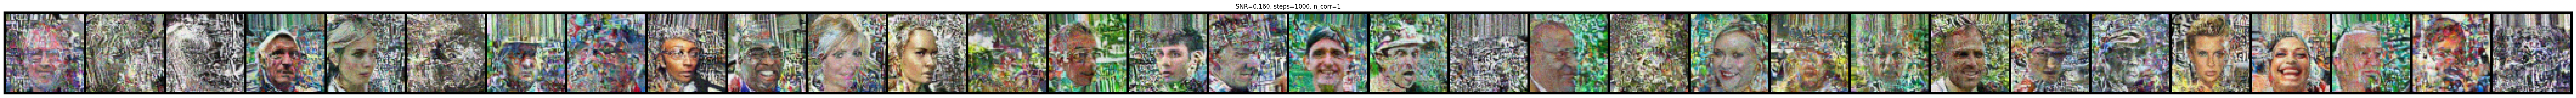

In [21]:

for (snr, num_steps, n_corrector_steps), x_final in zip(config_list, x_final_list):
    x_final_vis = per_image_minmax_to_01(x_final)
    grid = make_grid(x_final_vis, nrow=num_samples)
    plt.figure(figsize=(3 * num_samples, 3))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis("off")
    plt.title(f"SNR={snr:.3f}, steps={num_steps}, n_corr={n_corrector_steps}")
    plt.show()
